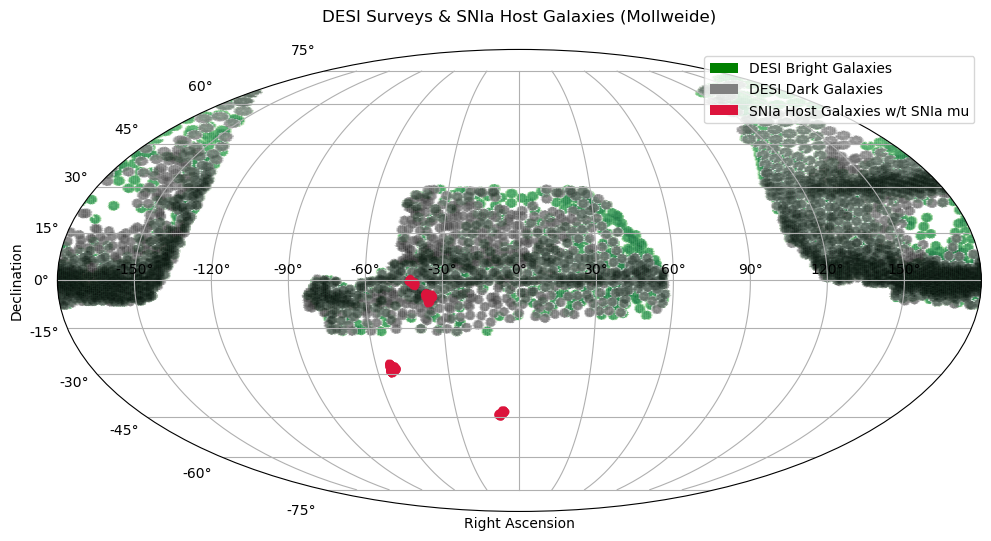

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

# === Load DESI Bright ===
bright = Table.read("desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load SNIa Metadata CSV ===
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid host coordinates
valid_hosts = (sn_df['HOST_RA'] != -999) & (sn_df['HOST_DEC'] != -999)
host_ra = sn_df.loc[valid_hosts, 'HOST_RA'].values
host_dec = sn_df.loc[valid_hosts, 'HOST_DEC'].values
ra_host, dec_host = prepare_coords(host_ra, host_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts (scatter instead of density)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')

# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='crimson', label='SNIa Host Galaxies w/t SNIa mu', alpha=1)
]
ax.legend(handles=legend_elements, loc='upper right')

# Plot settings
ax.set_title('DESI Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

# Creating a CSV with Just the SNIa missing the Host Galaxy infromation #

In [1]:
import pandas as pd

# Load the metadata CSV
df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter for invalid host galaxy coordinates (i.e., -999)
bad_host_mask = (df['HOST_RA'] == -999) | (df['HOST_DEC'] == -999)
bad_hosts = df[bad_host_mask]

# Save to a new CSV
bad_hosts.to_csv("snia_with_missing_host_coords.csv", index=False)

print(f"Saved {len(bad_hosts)} SNe Ia with invalid host coordinates to snia_with_bad_hosts.csv")

Saved 194 SNe Ia with invalid host coordinates to snia_with_bad_hosts.csv


# The .csv file containing Metadata Not only Has Missing Host Galaxy location information but is also missing the SNIa Locaiton #

Lets see if all the missing analysis data came form the LOW-Z data-set 

In [3]:
from astropy.io import fits
import pandas as pd

# Path to your file
fits_path = "/global/homes/m/myc21/first_paper/DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"

# Open the FITS file
with fits.open(fits_path) as hdul:
    print("\n=== HDU 0 (PRIMARY) ===")
    print(f"Type: {type(hdul[0])}")
    print("Header:")
    print(repr(hdul[0].header))
    print("Data:")
    print(hdul[0].data)  # Should be None or empty

    print("\n=== HDU 1 (Binary Table) ===")
    data = hdul[1].data
    print(f"Number of rows: {len(data)}")
    print("Column names:")
    print(data.columns.names)
    print("\nFirst 3 rows:")
    print(data[:3])


=== HDU 0 (PRIMARY) ===
Type: <class 'astropy.io.fits.hdu.image.PrimaryHDU'>
Header:
SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    1 / number of data axes                            
NAXIS1  =                    0 / length of data axis 1                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
HIERARCH CODE_IVERSION =    24 / Internal SNFTSIO code version                  
HIERARCH SNANA_PATH = '        ' / SNANA code directory                         
HIERARCH SNANA_VERSION = 'v11_05n-89-g9b3758e' / SNANA version                  
SURVEY  = 'DES5YR_LOWZ_COMBINED' / Survey                                       
HIERARCH SUBSURVEY_FLAG

In [7]:
from astropy.io import fits

# Path to your HEAD.FITS file
fits_path = "/global/homes/m/myc21/first_paper/DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"

# Open the FITS file and extract SNIDs
with fits.open(fits_path) as hdul:
    header_table = hdul[1].data  # HDU 1 is the binary table
    snids = header_table['SNID']

# Print SNIDs
print("List of SNIDs:")
for snid in snids:
    print(snid)

print(len(snids
         
         
         
         
         
         
         
         
         
         ))
      

List of SNIDs:
2004ef
2005am
2005el
2005eq
2005hc
2005hj
2005hk
2005iq
2005ir
2005kc
2005ke
2005ki
2005lu
2005mc
2005M
2005na
2006ax
2006bd
2006br
2006bt
2006D
2006ef
2006ej
2006et
2006ev
2006gj
2006gt
2006hb
2006is
2006kf
2006ob
2006os
2006ot
2006X
2007af
2007ai
2007al
2007ax
2007ba
2007bc
2007bd
2007bm
2007ca
2007cg
2007N
2007S
2007sr
2008bf
2007A
2007hj
2007if
2007le
2007nq
2007ux
2008ae
2008ar
2008bi
2008bz
2008C
2008cd
2008cf
2008fr
2008gl
2008hj
2008hv
2009ad
2009al
2009dc
2009D
2009ds
2009Y
2009le
2008J
2007jd
2006hx
2008gp
2004gc
2006mr
2006bh
2009aa
2007ol
2007on
2008hu
2007st
2007as
2008ff
2005W
2005bg
2007mm
2010ae
2006fw
2008ia
2004eo
2005al
2005bl
2008fp
2005ku
2009J
2008bc
2009F
2006lu
2009I
2006dd
2005be
2008O
2007so
2008fl
2005gj
2005ag
2008fw
2005bo
2007hx
2005A
2008bt
2004ey
2008cc
2004gs
2008fu
2007jg
2008bd
2009P
2008bq
2006py
2008gg
2007jh
2008ha
2008go
2009ab
2008R
2009ag
2006eq
2004dt
2004gu
2009cz
iPTF13ebh
2011iv
2007co
2005ms
2007qe
2006ac
2007ae
2005ew
2006ke

In [17]:
import pandas as pd
from astropy.io import fits

# --- Step 1: Load the metadata CSV ---
csv_path = "DES5YR_DESI_match_data/snia_with_missing_host_coords.csv"
meta_df = pd.read_csv(csv_path)
print(meta_df.columns)
print("Length of SNIa with Missing HostGal Info: " + str(len(meta_df)))

# --- Step 2: Load the FITS header file ---
fits_path = "DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"
with fits.open(fits_path) as hdul:
    header_data = hdul[1].data
    fits_df = pd.DataFrame(header_data.byteswap().newbyteorder())
print(fits_df.columns)

merged_df = pd.merge(meta_df, fits_df[['SNID', 'RA', 'DEC']], on='SNID', how='left')

# --- Step 4: Save the merged file ---
merged_df.to_csv("DES-SN5YR_HD+MetaData_with_coords.csv", index=False)
print("✅ Saved: DES-SN5YR_HD+MetaData_with_coords.csv")

Index(['SNID', 'CIDint', 'IDSURVEY', 'TYPE', 'zHEL', 'zHELERR', 'zCMB',
       'zCMBERR', 'zHD', 'zHDERR', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_ZSPEC',
       'HOST_ZSPECERR', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'HOST_DDLR',
       'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'HOST_COLOR', 'HOST_COLOR_ERR',
       'PKMJD', 'PKMJDERR', 'x1', 'x1ERR', 'c', 'cERR', 'mB', 'mBERR',
       'mB_corr', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'NDOF',
       'FITPROB', 'PROB_SCONE', 'PROB_SNIRFV19', 'PROB_SNNDESCC',
       'PROB_SNNJ17', 'PROB_SNNV19', 'MU', 'MUERR_FINAL', 'PROBCC_BEAMS',
       'biasCor_mu', 'biasCor_muCOVSCALE', 'biasCor_muCOVADD'],
      dtype='object')
Length of SNIa with Missing HostGal Info: 195
Index(['SUBSURVEY', 'SNID', 'IAUC', 'FAKE', 'MASK_FLUXCOR_SNANA', 'RA', 'DEC',
       'PIXSIZE', 'NXPIX', 'NYPIX',
       ...
       'HOSTGAL_SB_FLUXCAL_D', 'HOSTGAL_SB_FLUXCAL_E', 'HOSTGAL_SB_FLUXCAL_F',
       'HOSTGAL_SB_FLUXCAL_G', 'HOSTGAL_SB_FLUXCAL_H', 'PEAKMJD',
       'M

# lets Just Look at Astroquery #

In [1]:
from astroquery.ipac.ned import Ned

# Choose a supernova name to query
sn_name = "2001ay"

# Query NED
result_table = Ned.query_object(sn_name)

# Display results
print(result_table)


RemoteServiceError: The remote service returned the following error message.
ERROR: The object name that you have submitted is not currently recognized by the NED name interpreter.

116


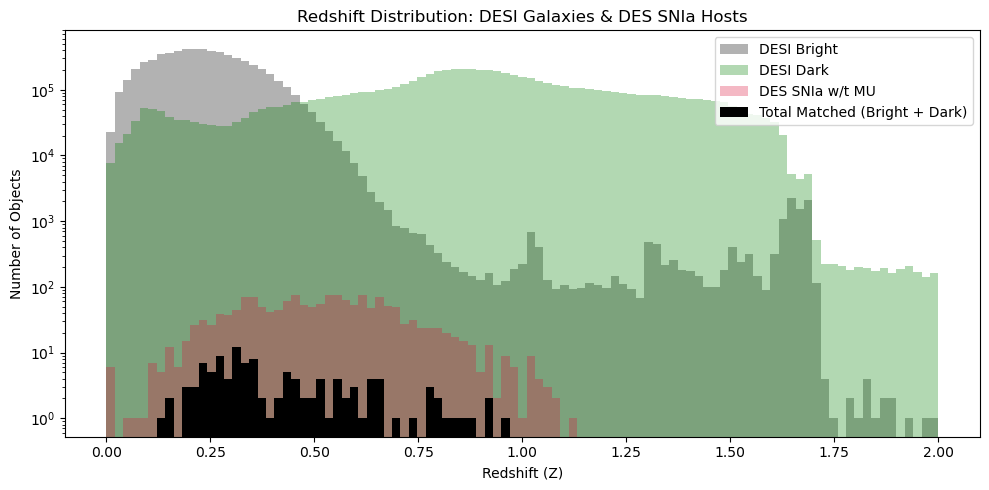

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

def load_redshift(path, label):
    data = Table.read(path)
    mask = (data['SPECTYPE'] == 'GALAXY') & (data['ZWARN'] == 0)
    return data['Z'][mask], label

# === Load Bright & Dark DESI Galaxies === #
z_bright, label_bright = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata.fits", "DESI Bright")
z_dark, label_dark = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits", "DESI Dark")

# === Load SNIa Host Galaxy Redshifts from CSV === #
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")  # replace path
z_host = sn_df.loc[sn_df['HOST_ZSPEC'] != -999, 'HOST_ZSPEC'].values
label_host = "DES SNIa w/t MU"

# === Plot === #
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 2, 100)

plt.hist(z_bright, bins=bins, alpha=0.3, label=label_bright, color='black', histtype='stepfilled')
plt.hist(z_dark, bins=bins, alpha=0.3, label=label_dark, color='green', histtype='stepfilled')
plt.hist(z_host, bins=bins, alpha=0.3, label=label_host, color='crimson', histtype='stepfilled')
plt.hist(z_total, bins=bins, alpha=1, label='Total Matched (Bright + Dark)', color='black', histtype='stepfilled')
print(len(z_total))


plt.title("Redshift Distribution: DESI Galaxies & DES SNIa Hosts")
plt.xlabel("Redshift (Z)")
plt.ylabel("Number of Objects")
plt.legend(loc='upper right')
plt.yscale("log")
plt.tight_layout()
plt.show()